In [2]:
import pandas as pd
import seaborn as sns
from scipy.stats import skew, kurtosis
import importlib
import utils
importlib.reload(utils)
import matplotlib.pyplot as plt



df = utils.import_dataset('customer.csv')
df.head()


Dataset importado exitosamente desde customer.csv


,Unnamed: 0,Customer,State,CustomerLifetimeValue,Response,Coverage,Education,EffectiveToDate,EmploymentStatus,Gender,...,MonthsSincePolicyInception,NumberofOpenComplaints,NumberofPolicies,PolicyType,Policy,RenewOfferType,SalesChannel,ClaimAmount,VehicleClass,VehicleSize
0,0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


In [3]:
# ANÁLISIS DE BOXPLOT PARA DETECCIÓN DE OUTLIERS
# categoria que muestra más outliers: Basic, Extended Coverage, Premium
outliers_basic = utils.outliers_iqr(df, 'Coverage', 'Basic', 'ClaimAmount')
print(f"Número de outliers detectados en Basic Claims usando el método del IQR: {outliers_basic.sum()}")
##print(f"Tipo: {type(outliers_basic)}")
#print(f"Índices: {outliers_basic.index[:10]}")  # Primeros 10 índices
#print(f"Shape: {outliers_basic.shape}")

outliers_extended = utils.outliers_iqr(df, 'Coverage', 'Extended', 'ClaimAmount')
print(f"Número de outliers detectados en Extended Claims usando el método del IQR: {outliers_extended.sum()}")

outliers_premium = utils.outliers_iqr(df, 'Coverage', 'Premium', 'ClaimAmount')
print(f"Número de outliers detectados en Premium Claims usando el método del IQR: {outliers_premium.sum()}")
print("\nConclusión: En base a los resultados arrojados, se concluye que la categoría Basic muestra la mayor cantidad de outliers.")
print("Con respecto al riesgo, Basic, al tener la mayor cantidad de outliers, presenta un mayor riesgo debido a la alta variabilidad en montos reclamados, en comparación con las otras categorías.")

Número de outliers detectados en Basic Claims usando el método del IQR: 199
Número de outliers detectados en Extended Claims usando el método del IQR: 100
Número de outliers detectados en Premium Claims usando el método del IQR: 54

Conclusión: En base a los resultados arrojados, se concluye que la categoría Basic muestra la mayor cantidad de outliers.
Con respecto al riesgo, Basic, al tener la mayor cantidad de outliers, presenta un mayor riesgo debido a la alta variabilidad en montos reclamados, en comparación con las otras categorías.


In [4]:
# HEATMAP DE CORRELACIÓN
#¿Qué variables están más correlacionadas con ClaimAmount?
print('Según la gráfica, la variable que presenta mayor correlación con ClaimAmount es\nMontthlyPremiumAuto con 0.63,\n'
'le sigue CustomerLifetineValue con 0.23.')
#¿Hay correlaciones inesperadas?
print('La relacion inesperada se da entre:\nCustomerLifetimeValue y MonthlyPremiumAuto con 0.40,\n')

Según la gráfica, la variable que presenta mayor correlación con ClaimAmount es
MontthlyPremiumAuto con 0.63,
le sigue CustomerLifetineValue con 0.23.
La relacion inesperada se da entre:
CustomerLifetimeValue y MonthlyPremiumAuto con 0.40,



In [5]:
# VIOLINPLOT: distribucion de clientes según tamaño de vehiculo.
#¿Qué categoría muestra mayor concentración?
# 1 - Estadistica Descriptiva por categoría de vehiculo
vehicle_size = df['VehicleSize'].unique()
for size in vehicle_size:
    size_claims = df[df['VehicleSize'] == size]['ClaimAmount']
    print(f"{size}:")
    print(f"  - Media: ${size_claims.mean():.2f}")
    print(f"  - Mediana: ${size_claims.median():.2f}")
    print(f"  - Desviación estándar: ${size_claims.std():.2f}")
    print(f"  - Coeficiente de variación: {size_claims.std()/size_claims.mean():.2f}")
    print(f"  - Cantidad de clientes: {len(size_claims)}\n")
print("Nota: a mayor coeficiente de variación, menor concentración.\n")

# 2 - Análisis por distribución de datos (concentración)
for size in vehicle_size:
    size_claims = df[df['VehicleSize'] == size]['ClaimAmount']
    asimetria = skew(size_claims.dropna())
    curtosis = kurtosis(size_claims.dropna())

    print(f"{size}:")
    print(f"  - Asimetría: {asimetria:.2f}")
    print(f"  - Curtosis: {curtosis:.2f}\n")

#Interpetación de concentración:
if asimetria > 0:
    print("Distribución asimétrica positiva (sesgo a la derecha): La mayoría de los clientes tienen montos reclamados bajos, pero hay algunos con montos muy altos.")
elif asimetria < 0:
    print("Distribución asimétrica negativa (sesgo a la izquierda): La mayoría de los clientes tienen montos reclamados altos, pero hay algunos con montos muy bajos.")
else:
    print("Distribución normal: La distribución de los montos reclamados es simétrica.")

print("Distribución leptocúrtica: La mayoría de los clientes tienen montos reclamados cercanos a la media, con pocos valores extremos.")

#¿Qué sugiere esto sobre el perfil del cliente?
#¿Qué sugiere esto sobre el perfil del cliente?

print("\nPERFIL GENERAL DEL CLIENTE\n")

print("CARACTERÍSTICAS GENERALES DE LA DISTRIBUCIÓN:")
print("• Asimetría positiva (1.68-1.76): Comportamiento típico de seguros")
print("• Curtosis alta (5.58-6.30): Distribución leptocúrtica")
print("• Coeficientes de variación moderados (0.56-0.71): Variabilidad controlada\n")

print("PERFIL DEL CLIENTE TÍPICO:")
print("El análisis revela que el cliente promedio presenta un comportamiento")
print("predecible y consistente en sus reclamaciones:")
print()
print("1. COMPORTAMIENTO MAYORITARIO:")
print("   • La mayoría de clientes realizan reclamaciones de montos bajos")
print("   • Pocos clientes generan reclamaciones de montos muy altos")
print("   • La concentración alrededor de la media es alta")
print()
print("2. PREDICTIBILIDAD:")
print("   • Los valores extremos son raros (distribución leptocúrtica)")
print("   • El comportamiento está concentrado cerca del promedio")
print("   • La variabilidad es moderada y manejable")


Medsize:
  - Media: $420.08
  - Mediana: $362.90
  - Desviación estándar: $291.83
  - Coeficiente de variación: 0.69
  - Cantidad de clientes: 6424

Small:
  - Media: $489.43
  - Mediana: $451.20
  - Desviación estándar: $272.01
  - Coeficiente de variación: 0.56
  - Cantidad de clientes: 1764

Large:
  - Media: $426.06
  - Mediana: $378.26
  - Desviación estándar: $302.62
  - Coeficiente de variación: 0.71
  - Cantidad de clientes: 946

Nota: a mayor coeficiente de variación, menor concentración.

Medsize:
  - Asimetría: 1.76
  - Curtosis: 6.30

Small:
  - Asimetría: 1.68
  - Curtosis: 5.58

Large:
  - Asimetría: 1.76
  - Curtosis: 5.67

Distribución asimétrica positiva (sesgo a la derecha): La mayoría de los clientes tienen montos reclamados bajos, pero hay algunos con montos muy altos.
Distribución leptocúrtica: La mayoría de los clientes tienen montos reclamados cercanos a la media, con pocos valores extremos.

PERFIL GENERAL DEL CLIENTE

CARACTERÍSTICAS GENERALES DE LA DISTRIBUCIÓ

In [41]:
# Pairplot y relaciones entre variables
# 1- ¿Qué relaciones visuales surgen?
print("1. CustomerLifetimeValue vs MonthlyPremiumAuto:")
print("   • Correlación POSITIVA moderada-fuerte")
print("2. ClaimAmount vs MonthlyPremiumAuto:")
print("   • Correlación POSITIVA moderada-fuerte")

# 2 -¿Hay alguna correlación visible entre ingresos y siniestros?
print("3. Income vs ClaimAmount:")
print("   • Correlación débil - inexistente, patrones difusos")

1. CustomerLifetimeValue vs MonthlyPremiumAuto:
   • Correlación POSITIVA moderada-fuerte
2. ClaimAmount vs MonthlyPremiumAuto:
   • Correlación POSITIVA moderada-fuerte
3. Income vs ClaimAmount:
   • Correlación débil - inexistente, patrones difusos


In [42]:
# Intevalo de Confianza
# 1- ¿Qué significa este intervalo para un gerente de seguros?
print("Un intervalo de confianza del 95% para el monto promedio de siniestros entre $~428 y $~440 significa que el gerente de seguros puede estar 95% seguro que el verdadero monto promedio de siniestros de toda la población de clientes se encuentra dentro de este rango. Esto le permite tomar decisiones informadas sobre reservas financieras, estrategias de pricing y gestión de riesgos, sabiendo que hay una alta probabilidad de que el monto real esté dentro de este intervalo.")

# Prueba de Hipótesis: Los clientes con cobertura Premium tienen un monto promedio de siniestros diferente al de cobertura Básica.
#? H0: media_basic = media_premium
#? H1: media_basic != media_premium
#? Nivel de significancia: α = 0.05 (5%)

#* Resultados: T-statistic: -19.179181383624748, p-value: 3.1560481079936134e-69
print("\nPRUEBA DE HIPÓTESIS: BASIC vs PREMIUM \n")
Valor_t = -19.179181383624748
p_value = 3.1560481079936134e-69
print("CONCLUSIÓN AL 5%:")
print("RECHAZAMOS H₀")
print()
print("INTERPRETACIÓN:")
print("• p-value (3.16e-69) < 0.05")
print("• Evidencia EXTREMADAMENTE FUERTE contra H₀")
print("• T-statistic negativo (-19.18) indica que μ_Basic < μ_Premium")
print("• Premium tiene montos promedio SIGNIFICATIVAMENTE más altos que Básica,ésto valida que la segmentación actual es correcta")




Un intervalo de confianza del 95% para el monto promedio de siniestros entre $~428 y $~440 significa que el gerente de seguros puede estar 95% seguro que el verdadero monto promedio de siniestros de toda la población de clientes se encuentra dentro de este rango. Esto le permite tomar decisiones informadas sobre reservas financieras, estrategias de pricing y gestión de riesgos, sabiendo que hay una alta probabilidad de que el monto real esté dentro de este intervalo.

PRUEBA DE HIPÓTESIS: BASIC vs PREMIUM 

CONCLUSIÓN AL 5%:
RECHAZAMOS H₀

INTERPRETACIÓN:
• p-value (3.16e-69) < 0.05
• Evidencia EXTREMADAMENTE FUERTE contra H₀
• T-statistic negativo (-19.18) indica que μ_Basic < μ_Premium
• Premium tiene montos promedio SIGNIFICATIVAMENTE más altos que Básica,ésto valida que la segmentación actual es correcta


In [43]:
# Storytelling con datos.
print('- Destacar insights relevantes, no solo gráficos bonitos. ')
print('- Apoyarse en preguntas clave: ¿Qué? ¿Por qué? ¿Y ahora qué? ')
print('- Usar títulos claros y lenguaje no técnico para comunicar resultados. ')

- Destacar insights relevantes, no solo gráficos bonitos. 
- Apoyarse en preguntas clave: ¿Qué? ¿Por qué? ¿Y ahora qué? 
- Usar títulos claros y lenguaje no técnico para comunicar resultados. 


Ejercicio 1: Crear un gráfico que muestre cómo varía ClaimAmount según Coverage y VehicleSize,
e interpretar qué conclusiones surgen sobre el perfil de riesgo.



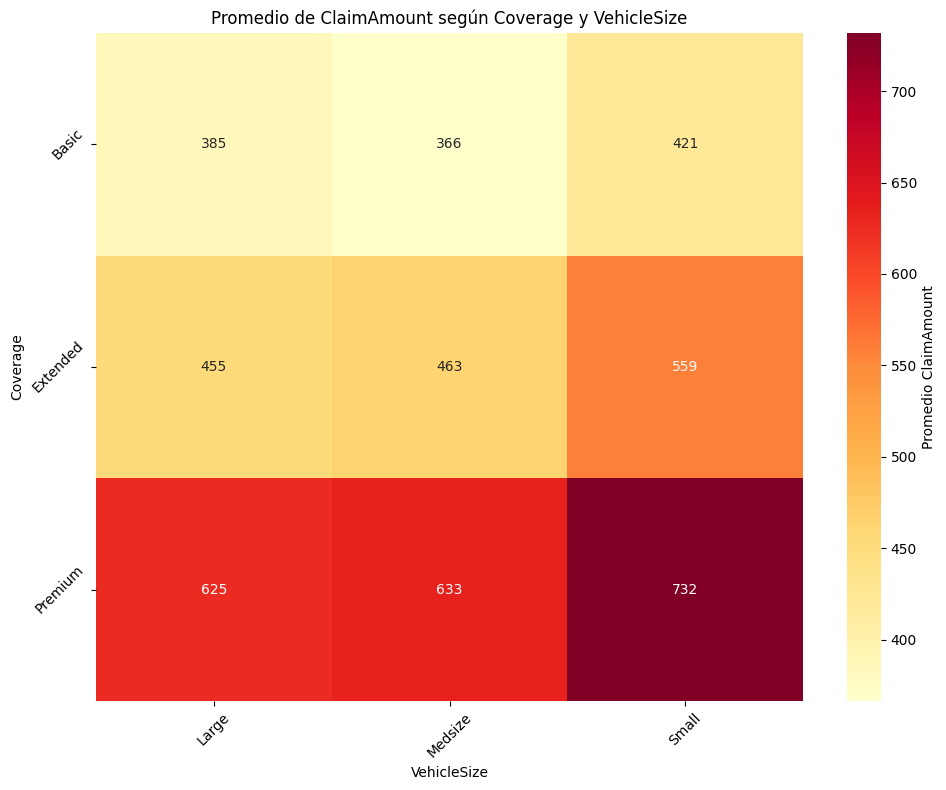


ANÁLISIS DEL HEATMAP: PERFIL DE RIESGO

LECTURA DE COLORES:
Amarillo claro: Montos bajos (~$366-$421)
Naranja: Montos medios (~$455-$559)
Rojo oscuro: Montos altos (~$625-$732)

INSIGHTS PRINCIPALES:

1. JERARQUÍA DE COVERAGE (vertical):
   Premium: MAYOR RIESGO ($625-$732)
   Extended: RIESGO MEDIO ($455-$559)
   Basic: MENOR RIESGO ($366-$421)

2. IMPACTO DEL VEHICLE SIZE (horizontal):
   Small: Reclamaciones más altas en todas las categorías
   Medsize: Valores intermedios
   Large: Valores intermedios

3. COMBINACIONES CRÍTICAS:
   MÁXIMO RIESGO: Premium + Small ($732)
   RIESGO ALTO: Premium + Medsize ($633)
   MENOR RIESGO: Basic + Medsize ($366)


CONCLUSIONES SOBRE PERFIL DE RIESGO:
SEGMENTACIÓN EFECTIVA: Coverage diferencia claramente el riesgo
FACTOR VEHÍCULO: Small vehicles = MAYOR riesgo en todas las categorías
INSIGHT CLAVE: El comportamiento del conductor importa más que el tamaño físico
ESTRATEGIA: Pricing diferenciado por matriz Coverage x VehicleSize


In [6]:
print('Ejercicio 1: Crear un gráfico que muestre cómo varía ClaimAmount según Coverage y VehicleSize,\n' \
'e interpretar qué conclusiones surgen sobre el perfil de riesgo.\n')

correlaciones = df.groupby(['Coverage', 'VehicleSize'])['ClaimAmount'].mean().unstack()
plt.figure(figsize=(10,8))
sns.heatmap(correlaciones, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Promedio ClaimAmount'})
plt.title('Promedio de ClaimAmount según Coverage y VehicleSize')
plt.ylabel('Coverage')
plt.xlabel('VehicleSize')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()
print()

print("ANÁLISIS DEL HEATMAP: PERFIL DE RIESGO\n")

print("LECTURA DE COLORES:")
print("Amarillo claro: Montos bajos (~$366-$421)")
print("Naranja: Montos medios (~$455-$559)")
print("Rojo oscuro: Montos altos (~$625-$732)")
print()

print("INSIGHTS PRINCIPALES:")
print()
print("1. JERARQUÍA DE COVERAGE (vertical):")
print("   Premium: MAYOR RIESGO ($625-$732)")
print("   Extended: RIESGO MEDIO ($455-$559)")
print("   Basic: MENOR RIESGO ($366-$421)")
print()

print("2. IMPACTO DEL VEHICLE SIZE (horizontal):")
print("   Small: Reclamaciones más altas en todas las categorías")
print("   Medsize: Valores intermedios")
print("   Large: Valores intermedios")
print()

print("3. COMBINACIONES CRÍTICAS:")
print("   MÁXIMO RIESGO: Premium + Small ($732)")
print("   RIESGO ALTO: Premium + Medsize ($633)")
print("   MENOR RIESGO: Basic + Medsize ($366)")
print()

print("\nCONCLUSIONES SOBRE PERFIL DE RIESGO:")
print("="*50)
print("SEGMENTACIÓN EFECTIVA: Coverage diferencia claramente el riesgo")
print("FACTOR VEHÍCULO: Small vehicles = MAYOR riesgo en todas las categorías")
print("INSIGHT CLAVE: El comportamiento del conductor importa más que el tamaño físico")
print("ESTRATEGIA: Pricing diferenciado por matriz Coverage x VehicleSize")
print("="*50)


Ejercicio 2: Usar pairplot para encontrar relaciones ocultas entre al menos 3 variables del dataset.
Escribir una conclusión al respecto.


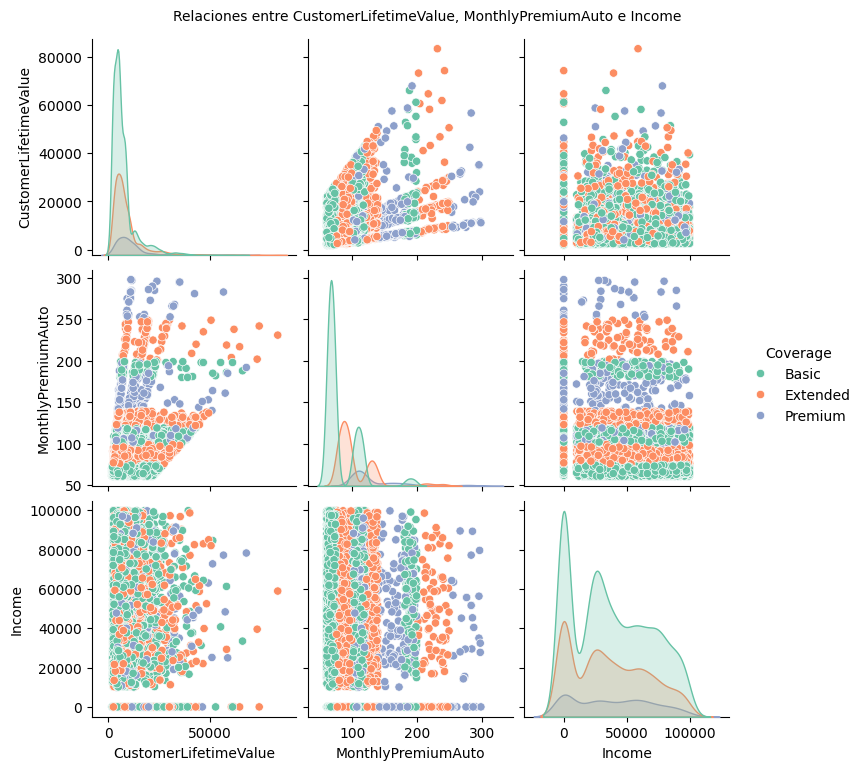


CONCLUSIONES SOBRE RELACIONES ENTRE VARIABLES:
• Variable más discriminante: MonthlyPremiumAuto
• Relación más fuerte: CLV ↔ MonthlyPremium
• Variable menos útil: Income (no discrimina)
• Segmentación efectiva: Coverage diferencia bien CLV y Prima


In [14]:
print("Ejercicio 2: Usar pairplot para encontrar relaciones ocultas entre al menos 3 variables del dataset.\n"
       "Escribir una conclusión al respecto.")

sns.pairplot(df, vars=['CustomerLifetimeValue', 'MonthlyPremiumAuto', 'Income'], hue='Coverage', diag_kind='kde', palette='Set2')
plt.suptitle('Relaciones entre CustomerLifetimeValue, MonthlyPremiumAuto e Income', y=1.02, fontsize=10)
plt.show()

print("\nCONCLUSIONES SOBRE RELACIONES ENTRE VARIABLES:")
print("• Variable más discriminante: MonthlyPremiumAuto")
print("• Relación más fuerte: CLV ↔ MonthlyPremium")
print("• Variable menos útil: Income (no discrimina)")
print("• Segmentación efectiva: Coverage diferencia bien CLV y Prima")

Ejercicio 4: Elaborar una visualización tipo “dashboard” con varios 
 (usar subplots o FacetGrid) que cuente una historia sobre los clientes más valiosos
 (CustomerLifetimeValue).


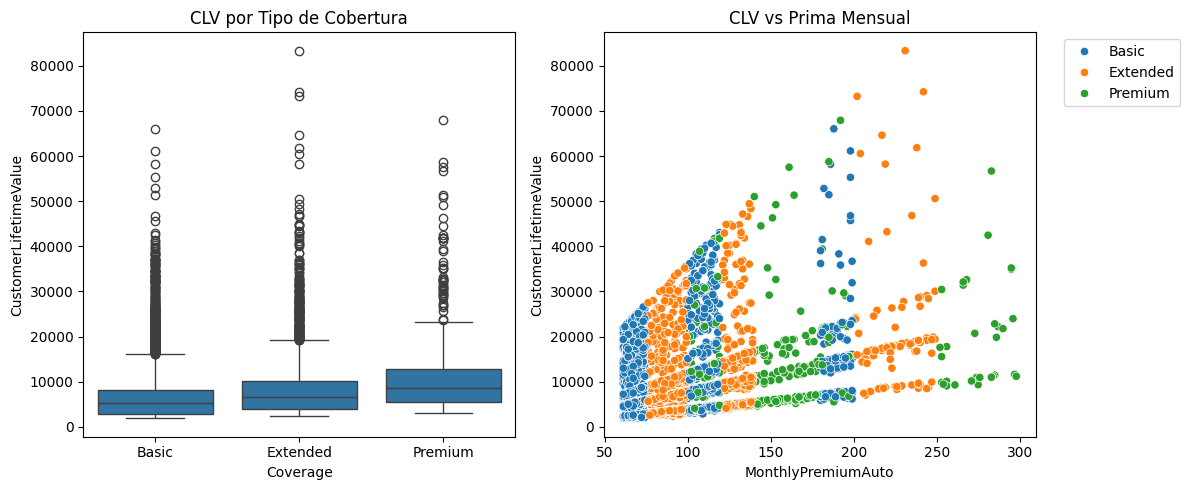

¿QUÉ VEMOS?
1. Premium tiene los CLV más altos
2. A mayor prima mensual, mayor CLV
4. Pocos clientes tienen CLV muy alto

¿POR QUÉ?
• Los clientes Premium pagan más y se quedan más tiempo
• Mayor cobertura = mayor valor para la empresa
• La mayoría de clientes tienen CLV bajo/medio

¿Y AHORA QUÉ?
• Enfocar esfuerzos en retener clientes Premium
• Ofrecer actualizaciones o mejoras a Basic y Extended
• Cuidar especialmente a los pocos clientes de CLV alto


In [22]:
print("Ejercicio 4: Elaborar una visualización tipo “dashboard” con varios \n"
" (usar subplots o FacetGrid) que cuente una historia sobre los clientes más valiosos\n"
" (CustomerLifetimeValue).")

plt.figure(figsize=(12, 5))

# Gráfico 1: CLV por Coverage
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Coverage', y='CustomerLifetimeValue')
plt.title('CLV por Tipo de Cobertura')
plt.ylabel('CustomerLifetimeValue')

# Gráfico 2: CLV vs Prima (MonthlyPremiumAuto)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='MonthlyPremiumAuto', y='CustomerLifetimeValue', hue='Coverage')
plt.title('CLV vs Prima Mensual')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("¿QUÉ VEMOS?")
print("1. Premium tiene los CLV más altos")
print("2. A mayor prima mensual, mayor CLV")
print("4. Pocos clientes tienen CLV muy alto")

print("\n¿POR QUÉ?")
print("• Los clientes Premium pagan más y se quedan más tiempo")
print("• Mayor cobertura = mayor valor para la empresa")
print("• La mayoría de clientes tienen CLV bajo/medio")

print("\n¿Y AHORA QUÉ?")
print("• Enfocar esfuerzos en retener clientes Premium")
print("• Ofrecer actualizaciones o mejoras a Basic y Extended")
print("• Cuidar especialmente a los pocos clientes de CLV alto")